Bollinger Bands Indikator

Bollinger Bands adalah indikator teknikal yang digunakan untuk mengukur volatilitas pasar dan mengidentifikasi kemungkinan area overbought atau oversold. Komponen bollinger bands.. 
1. Middle band
2. Upper band
3. Lower band

In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt
from matplotlib import pyplot as plt
import yfinance as yf

In [3]:
assets = ["XRP-USD"]
data = yf.download(assets, start="2024-01-01", end="2025-04-29")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [4]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,XRP-USD,XRP-USD,XRP-USD,XRP-USD,XRP-USD
Date,,,,,
2024-01-01,0.630082,0.631275,0.609636,0.615656,729315153
2024-01-02,0.625363,0.638627,0.623182,0.630094,1326197378
2024-01-03,0.582580,0.637770,0.538766,0.625381,3406740412
2024-01-04,0.588226,0.593941,0.572955,0.582577,1452005657
2024-01-05,0.576486,0.589413,0.558444,0.588197,1509144162


In [11]:
def count_bollinger(dataawal, window = 20) :
    
    
    data = dataawal[['Close']].copy()

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.droplevel('Ticker')

    data['SMA-20'] = data['Close'].rolling(window).mean()
    data['STD'] = data['Close'].rolling(window).std()

    data['Upper']= data['SMA-20'] + (2 * data['STD'])
    data['Lower']= data['SMA-20'] - (2 * data['STD'])

    return data



In [ ]:
xrp_df = count_bollinger(data, 20)
xrp_df.head()

Price,Close,SMA-20,STD,Upper,Lower
Date,,,,,
2024-01-01,0.630082,NaN,NaN,NaN,NaN
2024-01-02,0.625363,NaN,NaN,NaN,NaN
2024-01-03,0.582580,NaN,NaN,NaN,NaN
2024-01-04,0.588226,NaN,NaN,NaN,NaN
2024-01-05,0.576486,NaN,NaN,NaN,NaN


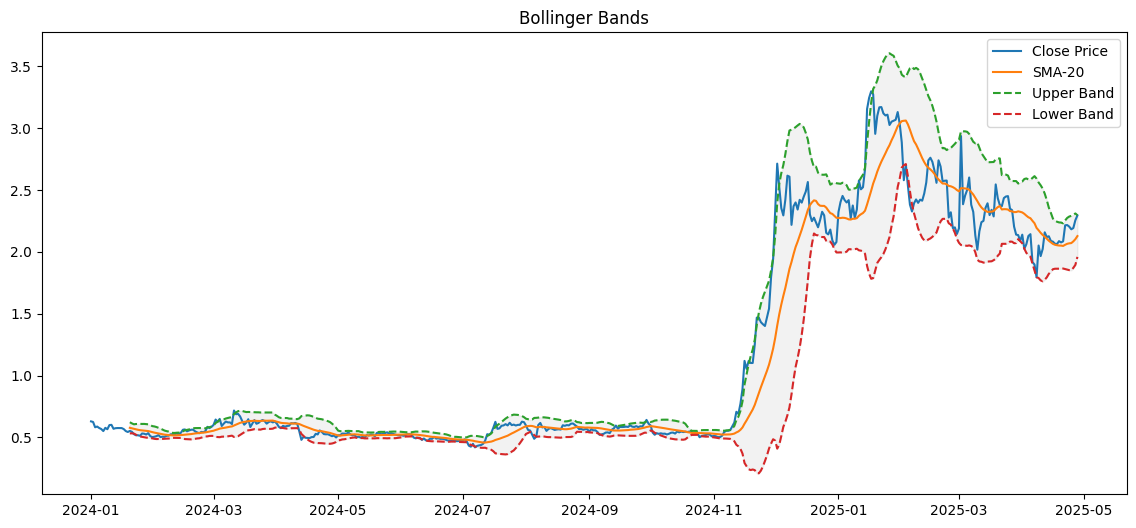

In [15]:
plt.figure(figsize=(14,6))
plt.plot(xrp_df['Close'], label='Close Price')
plt.plot(xrp_df['SMA-20'], label = 'SMA-20')
plt.plot(xrp_df['Upper'], label = 'Upper Band', linestyle='--')
plt.plot(xrp_df['Lower'], label = 'Lower Band', linestyle='--')
plt.fill_between(xrp_df.index, xrp_df['Lower'], xrp_df['Upper'], color='gray', alpha=0.1)
plt.legend()
plt.title("Bollinger Bands")
plt.show()



In [18]:
def detect_flexible_short_signal(data):
    # Status apakah kita sedang menunggu reversal dari breakout
    data['Volume_Spike']= 0
    in_breakout = False
    signals = []

    for i in range(1, len(data)):
        close = data['Close'].iloc[i]
        upper = data['Upper'].iloc[i]
        vol_spike = data['Volume_Spike'].iloc[i]

        # Cek apakah kita sedang dalam breakout
        if not in_breakout:
            if close > upper:
                in_breakout = True  # Mulai monitor reversal
                signals.append(False)
            else:
                signals.append(False)
        else:
            # Tunggu sampai harga kembali masuk ke bawah upper band
            if close < upper and vol_spike:
                signals.append(True)  # Sinyal short!
                in_breakout = False   # Reset status
            elif close < upper:
                signals.append(False)  # Harga masuk tapi tanpa volume spike
                in_breakout = False
            else:
                signals.append(False)  # Masih dalam breakout

    # Tambahkan baris awal yang hilang (karena loop mulai dari 1)
    signals = [False] + signals
    data['Flexible_Short_Signal'] = signals
    return data

In [19]:
xrp_df2= detect_flexible_short_signal(xrp_df)
xrp_df2

Price,Close,SMA-20,STD,Upper,Lower,Volume_Spike,Flexible_Short_Signal
Date,,,,,,,
2024-01-01,0.630082,NaN,NaN,NaN,NaN,0,False
2024-01-02,0.625363,NaN,NaN,NaN,NaN,0,False
2024-01-03,0.582580,NaN,NaN,NaN,NaN,0,False
2024-01-04,0.588226,NaN,NaN,NaN,NaN,0,False
2024-01-05,0.576486,NaN,NaN,NaN,NaN,0,False
...,...,...,...,...,...,...,...
2025-04-24,2.204544,2.069529,0.108340,2.286208,1.852849,0,False
2025-04-25,2.183054,2.071495,0.110100,2.291694,1.851295,0,False
2025-04-26,2.193189,2.085259,0.107052,2.299364,1.871155,0,False


In [22]:
(xrp_df2["Flexible_Short_Signal"]== True).sum()

0